In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
!pip install astra_toolbox
import astra
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 29.6 MB/s eta 0:00:00


In [ ]:
# Here one defines the forward and backward operators in ASTRA
# for the LGS-forward function
class LPD_transform:
    def __init__(self,
                proj_geom,
                vol_geom):

        self.proj_geom = proj_geom
        self.vol_geom = vol_geom

    def forw(self, reconstruction):
        proj_id = astra.create_projector('cuda', self.proj_geom, self.vol_geom)
        rec_id = astra.data2d.create('-vol', self.vol_geom)

        f_sinogram = astra.create_sino(reconstruction, proj_id)[1]

        return f_sinogram

    def back(self, sinogram):
        proj_id = astra.create_projector('cuda', self.proj_geom, self.vol_geom)
        rec_id = astra.data2d.create('-vol', self.vol_geom)
        FBP = astra.astra_dict('FBP_CUDA')
        sinogram_id = astra.data2d.create('-sino', self.proj_geom, sinogram)
        # Create FBP reconstruction.
        cfg = FBP
        cfg['ReconstructionDataId'] = rec_id
        cfg['ProjectionDataId'] = sinogram_id
        cfg['option'] = { 'FilterType': 'none' }

        alg_id = astra.algorithm.create(cfg)
        astra.algorithm.run(alg_id)

        rec = astra.data2d.get(rec_id)
        # rec = torch.as_tensor(np.maximum(0, rec))

        astra.data2d.delete(sinogram_id)
        astra.projector.delete(proj_id)
        astra.algorithm.delete(alg_id)
        astra.data2d.delete(rec_id)

        return rec

# This class helps to compute backpropagation of ASTRA operators.
# NOTE! Don't ask how this works, it works and gives nice results.
# Sometimes this is how coding works :D
# based on
# https://github.com/odlgroup/odl/blob/25ec783954a85c2294ad5b76414f8c7c3cd2785d/odl/contrib/torch/operator.py#L33
class NumpyFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, forward_fun, backward_fun):
        ctx.forward_fun = forward_fun
        ctx.backward_fun = backward_fun

        x_np = x.detach().cpu().numpy()
        y_np= ctx.forward_fun(x_np)
        y = torch.from_numpy(y_np).to(x.device)
        ctx.save_for_backward(y)
        return y

    @staticmethod
    def backward(ctx, y):
        y_np = y.detach().cpu().numpy()
        x_np = ctx.backward_fun(y_np)
        x = torch.from_numpy(x_np).to(y.device)
        return x, None, None

class LPDIterModule(torch.nn.Module):
    def __init__(self, circ_PAT_Op, adjoint=False):
        super().__init__()
        self.circPAT = circ_PAT_Op
        self.adjoint = adjoint

    def forward(self, x):
        # x.shape: (N, C, H, W) or (N, C, D, H, W)
        forward_fun = (self.circPAT.back if self.adjoint else
                        self.circPAT.forw)
        # note: backward_fun is only an approximation to the transposed jacobian
        backward_fun = (self.circPAT.forw if self.adjoint else
                        self.circPAT.back)

        xi=x[0,0]

        y = NumpyFunction.apply(xi, forward_fun, backward_fun)
        y=y[None,None,:]
        return y

# Ellipse generator
def random_ellipses(num_of_ellipses: int,
                    size: tuple) -> torch.Tensor:

    # Pre-allocate PyTorch tensor for the ellipses
    ellipses = torch.zeros(size=((num_of_ellipses, ) + (size[0], size[1])))

    # Create linear spaces for the ellipses to be put into.
    # Note that x is a row vector and y is a column vector.
    x = torch.linspace(start=-size[0], end=size[1], steps=size[1])
    y = torch.linspace(start=-size[0], end=size[1], steps=size[0])[:,None]

    # Loop over the amount of ellipses needed.
    for k in range(num_of_ellipses):
        # Find a random points for center coordinates, height and width.
        x0 = np.random.randint(low=-size[0], high=size[0])
        y0 = np.random.randint(low=-size[1], high=size[1])
        a = np.random.randint(low=-size[0], high=size[0])
        b = np.random.randint(low=-size[1], high=size[1])

        # Use ellipse function to create them.
        ellipses[k,:,:] = ((x-x0)/a)**2 + ((y-y0)/b)**2 <= 1

        # Force the ellipse value to be random constant from uniform distribution
        # for each ellipse.
        ellipses[k,:,:][ellipses[k,:,:] == 1] = torch.rand(1)

    # Sum all ellipses together and normalize the data to be in [0,1].
    ellipses = torch.sum(ellipses, dim=0)
    ellipses /= torch.max(ellipses)

    return ellipses

### Class for the Learned Gradient Scheme (LGS) algorithm.
class LGS(nn.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 n_iter: int,
                 device='cuda'
                 ):
        super().__init__()

        ### Defining instance variables
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.n_iter = n_iter
        self.device = device
        self.relu = nn.ReLU()

        # Define learnable step-size parameter initialized as zeros.
        self.step_length = nn.Parameter(torch.zeros(1,1,1,1))

        LGS_layers = [
            nn.Conv2d(in_channels=self.in_channels, \
                                    out_channels=32, kernel_size=(3,3), padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3,3), padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3,3), padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=self.out_channels, \
                                    kernel_size=(3,3), padding=1),
        ]


        self.layers = nn.Sequential(*LGS_layers)
        self.layers2 = [self.layers for i in range(self.n_iter)]
        # self.layers2 = [nn.Sequential(*LGS_layers) for i in range(n_iter)]

    def forward(self,
                reconstruction: torch.Tensor,
                sinogram: torch.Tensor,
                # vol_geom,
                # proj_geom,
                forw_op,
                back_op) -> torch.Tensor:

        for i in range(self.n_iter):

            f_sinogram = forw_op(reconstruction)

            rec = back_op(f_sinogram-sinogram)

            u = torch.cat([reconstruction.to(self.device), rec.to(self.device)], dim=1)

            u = self.layers2[i].to(self.device)(u)

            df = -self.step_length.to(self.device) * u[:,0:1,:,:]

            reconstruction = reconstruction + df

        return self.relu(reconstruction)

tensor(1.)


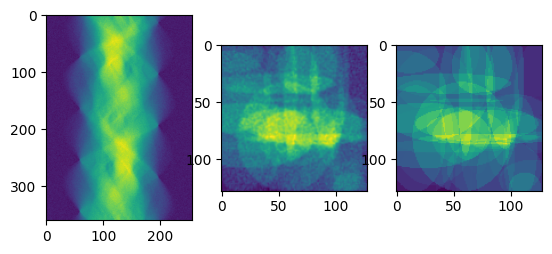

In [ ]:
# Assign device.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# If you want to use Tensorboard, here is summarywriter call
# writer = SummaryWriter()

# Generate testing data. Keep them as torch-tensor.
amount_of_test = 5
amount_of_ellipses = 50
image_size = (128, 128)
test_images = torch.zeros(size=(amount_of_test, ) + (image_size))
for k in range(amount_of_test):
    test_images[k,:,:] = random_ellipses(num_of_ellipses=amount_of_ellipses, size=image_size)
print(torch.max(test_images))

# test_images = torch.load('test_images.pt')
# image_size = (test_images.shape[1], test_images.shape[2])
# amount_of_test = test_images.shape[0]
# print(amount_of_test)

# Create a volume geometry of a size of variable "size".
vol_geom = astra.create_vol_geom(image_size)

# Define variables for the Fan-Beam projection.
num_of_lines = 256
start_angle = 0
end_angle = 2*np.pi
amount_of_angles = 360
angles = np.linspace(start_angle, end_angle, amount_of_angles)
SOD = 250
SDD = 260

# Create the Fan-Beam projction.
proj_geom = astra.create_proj_geom('fanflat', 1.0, num_of_lines, angles, SOD, SDD-SOD)

# Create a sinogram using the CPU or GPU.
proj_id = astra.create_projector('cuda',proj_geom, vol_geom)
# sinogram = astra.create_sino(ellipses, proj_id)[1]



# Add x% of mean zero noise on every test image.
percentage = 0.02
mean = 0

test_noisy_sinograms = torch.zeros(size=(amount_of_test, ) + (amount_of_angles, num_of_lines))
test_noisy_sinogram_ids = []
test_recos = torch.zeros(size=(amount_of_test, ) + (image_size))
for k in range(amount_of_test):
    proj_id = astra.create_projector('cuda',proj_geom, vol_geom)

    test_sinogram = astra.create_sino(test_images[k,:,:].numpy(), proj_id)[1]

    test_sinogram = torch.as_tensor(astra.create_sino(test_images[k,:,:].numpy(), proj_id)[1])
    noise = torch.normal(mean=mean, std=torch.max(test_sinogram), size=test_sinogram.shape) * percentage
    test_noisy_sinogram_ids.append(astra.data2d.create('-sino', proj_geom, (test_sinogram + noise).numpy()))
    test_noisy_sinograms[k,:,:] = test_sinogram + noise
    # Define reconstruction id.
    rec_id = astra.data2d.create('-vol', vol_geom)

    # Create Filtered Back-Projection operator.
    FBP = astra.astra_dict('FBP_CUDA')

    # Create FBP reconstruction.
    cfg = FBP
    cfg['ReconstructionDataId'] = rec_id
    cfg['ProjectionDataId'] = test_noisy_sinogram_ids[k]
    cfg['option'] = { 'FilterType': 'Hann' }

    alg_id = astra.algorithm.create(cfg)
    astra.algorithm.run(alg_id)

    # test_recos[k,:,:] = torch.as_tensor(np.maximum(0, astra.data2d.get(rec_id)))
    test_recos[k,:,:] = torch.as_tensor(astra.data2d.get(rec_id))
    # test_recos[k,:,:] = np.maximum(0, test_recos[k,:,:])

    # Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
    astra.data2d.delete(test_noisy_sinogram_ids[k])
    astra.projector.delete(proj_id)
    astra.algorithm.delete(alg_id)
    astra.data2d.delete(rec_id)


_, ax = plt.subplots(1,3)
ax[0].imshow(test_noisy_sinograms[0,:,:].numpy())
ax[1].imshow(test_recos[0,:,:].numpy())
ax[2].imshow(test_images[0,:,:].numpy())
plt.show()

In [ ]:
# Define loss functions.
train_loss = nn.MSELoss()
test_loss = nn.MSELoss()

# Defining forward and backward operators.
proj_id = astra.create_projector('cuda', proj_geom, vol_geom)
rec_id = astra.data2d.create('-vol', vol_geom)

LPD_operators = LPD_transform(proj_geom, vol_geom)

forw_op = LPDIterModule(LPD_operators, adjoint=False)
back_op = LPDIterModule(LPD_operators, adjoint=True)

# Initialize the network.
lgs = LGS(in_channels=2,
          out_channels=1,
          n_iter=10,
          device=device)

lgs_parameters = list(lgs.parameters())

# Defining PSNR-function.
def psnr(max_val, loss):

    psnr = 10 * np.log10((max_val**2)/(loss+1e-10))

    return psnr

In [ ]:
def network_training(network, iterations, learning_rate):
    optimizer = optim.Adam(lgs_parameters, lr=learning_rate)

    for k in range(iterations):
        train_image = random_ellipses(num_of_ellipses=amount_of_ellipses, size=image_size)

        proj_id = astra.create_projector('cuda',proj_geom, vol_geom)

        train_sinogram = astra.create_sino(train_image.numpy(), proj_id)[1]

        train_sinogram = torch.as_tensor(astra.create_sino(train_image.numpy(), proj_id)[1])
        noise = torch.normal(mean=mean, std=torch.max(train_sinogram), size=train_sinogram.shape) * percentage
        train_noisy_sinogram_id = astra.data2d.create('-sino', proj_geom, (train_sinogram + noise).numpy())
        train_noisy_sinogram = train_sinogram + noise
        # Define reconstruction id.
        rec_id = astra.data2d.create('-vol', vol_geom)

        # Create Filtered Back-Projection operator.
        FBP = astra.astra_dict('FBP_CUDA')

        # Create FBP reconstruction.
        cfg = FBP
        cfg['ReconstructionDataId'] = rec_id
        cfg['ProjectionDataId'] = train_noisy_sinogram_id
        cfg['option'] = { 'FilterType': 'Hann' }

        alg_id = astra.algorithm.create(cfg)
        astra.algorithm.run(alg_id)

        # test_recos[k,:,:] = torch.as_tensor(np.maximum(0, astra.data2d.get(rec_id)))
        train_reco = torch.as_tensor(astra.data2d.get(rec_id))
        # test_recos[k,:,:] = np.maximum(0, test_recos[k,:,:])

        # Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
        astra.data2d.delete(train_noisy_sinogram_id)
        astra.projector.delete(proj_id)
        astra.algorithm.delete(alg_id)
        astra.data2d.delete(rec_id)

        train_image = train_image[None,None,:,:].to(device)
        train_reco = train_reco[None,None,:,:].to(device)

        network.train()

        outputs = network(train_reco, train_noisy_sinogram.to(device), forw_op, back_op)

        optimizer.zero_grad()

        loss = train_loss(outputs, train_image)

        loss.backward()

        optimizer.step()

        if k % 500 == 0:
            test_outputs = torch.zeros(size=(test_recos.shape[0], ) + (image_size))
            for i in range(test_images.shape[0]):
                test_outputs[i] = network(test_recos[i][None,None,:,:].to(device), test_noisy_sinograms[i].to(device), forw_op, back_op)
            testing_loss = test_loss(test_outputs.to(device), test_images.to(device)).item()

            # writer.add_scalar('Test Loss', testing_loss, k)
            # writer.add_scalar('PSNR', psnr(torch.max(test_images).item(), testing_loss), k)
            # writer.add_image('Testing ouput', test_outputs[0,:,:], k, dataformats='HW')
            # writer.add_image('Testing Ground truth', test_images[0,:,:], k, dataformats='HW')
            # writer.flush()

            plt.figure()
            plt.subplot(1,2,1)
            plt.imshow(test_outputs[4,:,:].cpu().detach().numpy())
            plt.subplot(1,2,2)
            plt.imshow(test_images[4,:,:].cpu().detach().numpy())
            plt.show()

            print(f'PSNR after iter {k}: ', psnr(torch.max(test_images).item(), testing_loss))

    return network

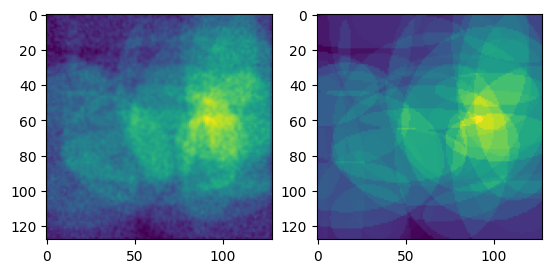

PSNR after iter 0:  29.24373864599207


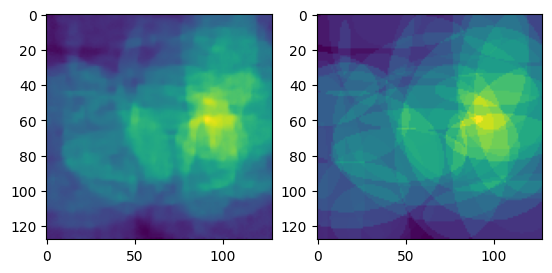

PSNR after iter 500:  31.75129427751652


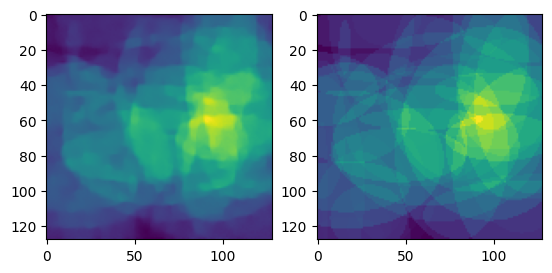

PSNR after iter 1000:  31.953861145401973


KeyboardInterrupt: 

In [ ]:
trained_network = network_training(lgs, 50001, 0.001)